# DOT Line-Item Classification: Predicting Significant Budget Modifications

Builds a binary classifier that flags DOT budget line items likely to see a
**significant modification** (Modified far from Adopted) using only
information available at Adopted-budget time. Same DOT scope and cleaning
as `dot_analysis.ipynb` (`Agency == "Department of Transportation"`).

Each step prints its own output for verification. **Stops after Step 7** —
no further tuning yet.

In [1]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 130)

DATA_DIR = "raw datasets"
BUDGET_PATH = f"{DATA_DIR}/DOT_Budget_2017_2027.csv"


## Step 1: Load

Read the DOT budget file and apply the same `Agency == "Department of
Transportation"` filter used in `dot_analysis.ipynb`. No modeling
assumptions yet -- just load, filter, and look.

In [2]:
budget_raw = pd.read_csv(BUDGET_PATH)
print("Raw file shape:", budget_raw.shape)

budget = budget_raw[budget_raw["Agency"] == "Department of Transportation"].copy()
print("DOT-only row count:", len(budget), "(expected ~172K)")

print("\nColumns:", list(budget.columns))
print("\nDtypes:")
print(budget.dtypes)
print("\nHead:")
budget.head()


Raw file shape: (334806, 9)
DOT-only row count: 172576 (expected ~172K)

Columns: ['Adopted', 'Agency', 'Budget Code', 'Expense Category', 'Modified', 'Post Adjustments', 'Pre-Encumbered', 'Year', 'Source_File']

Dtypes:
Adopted             float64
Agency                  str
Budget Code             str
Expense Category        str
Modified            float64
Post Adjustments    float64
Pre-Encumbered      float64
Year                  int64
Source_File             str
dtype: object

Head:


,Adopted,Agency,Budget Code,Expense Category,Modified,Post Adjustments,Pre-Encumbered,Year,Source_File
0,56261392.0,Department of Transportation,4125,HEAT LIGHT & POWER,53742028.0,0.00,0.0,2017,nyc-data-feed DOT 2017.csv
1,39071937.0,Department of Transportation,2002,SUPPLIES + MATERIALS - GENERAL,42563150.0,120.94,0.0,2017,nyc-data-feed DOT 2017.csv
2,32955700.0,Department of Transportation,4122,MAINT & OPER OF INFRASTRUCTURE,30104225.0,0.00,0.0,2017,nyc-data-feed DOT 2017.csv
3,27844600.0,Department of Transportation,3100,FULL YEAR POSITIONS,29090761.0,0.00,0.0,2017,nyc-data-feed DOT 2017.csv
4,30256607.0,Department of Transportation,1270,RENTALS - LAND BLDGS & STRUCTS,25870624.0,0.00,0.0,2017,nyc-data-feed DOT 2017.csv


**Column-name check.** The requested feature list (`Object Class Name` /
`Object Code Name`, `Budget Code Name`, a `Personal Service/OTPS indicator`)
doesn't literally exist in this file's schema — confirmed above, the real
columns are `Adopted`, `Agency`, `Budget Code`, `Expense Category`,
`Modified`, `Post Adjustments`, `Pre-Encumbered`, `Year`, `Source_File`.
Mapping used below, so nothing is silently assumed:

| Requested | Used here | Why |
|---|---|---|
| Fiscal Year | `Year` | same concept, different column name |
| Object Class Name / Object Code Name | `Expense Category` | the descriptive line-item label (142 unique values for DOT) — closest match |
| Budget Code Name | `Budget Code` | there's no separate descriptive-name column for the code; the code itself (995 unique values) is used as the categorical identifier |
| Personal Service/OTPS indicator | `ps_otps_indicator` (derived) | no such column exists; derived from `Expense Category` text via a keyword rule — built and audited in Step 3 below |
| Adopted amount | `Adopted` | present as-is |

## Step 2: Build Target

```
modification    = Modified - Adopted
significant_mod = 1  if |modification| >= 0.10 * |Adopted| AND |modification| >= 50000
                 = 1  if Adopted == 0 AND |modification| >= 50000
                 = 0  otherwise
```

In [3]:
modification = budget["Modified"] - budget["Adopted"]
abs_mod = modification.abs()
abs_adopted = budget["Adopted"].abs()

cond_pct_and_floor = (abs_adopted > 0) & (abs_mod >= 0.10 * abs_adopted) & (abs_mod >= 50_000)
cond_zero_adopted = (budget["Adopted"] == 0) & (abs_mod >= 50_000)

budget["modification"] = modification
budget["significant_mod"] = (cond_pct_and_floor | cond_zero_adopted).astype(int)

print("Class balance (significant_mod):")
counts = budget["significant_mod"].value_counts().rename({0: "0 (stable)", 1: "1 (significant mod)"})
pct = budget["significant_mod"].value_counts(normalize=True).rename({0: "0 (stable)", 1: "1 (significant mod)"}) * 100
balance = pd.DataFrame({"count": counts, "pct": pct.round(2)})
print(balance)


Class balance (significant_mod):
                      count    pct
significant_mod                   
0 (stable)           167320  96.95
1 (significant mod)    5256   3.05


## Step 3: Features

Drop anything derived from `Modified` (`Modified` itself, `modification`,
and — not requested but also excluded to stay strictly to the 5 requested
features — `Post Adjustments` / `Pre-Encumbered`, which are separate raw
budget-modification components, not part of the requested feature set).

No literal `Personal Service/OTPS indicator` column exists (confirmed in
Step 1), so one is derived here from `Expense Category` text using a
keyword rule, audited below before use.

In [4]:
# --- Derive ps_otps_indicator from Expense Category text ---
# Explicit-tag overrides first (categories that literally say OTPS or -PS),
# then a keyword rule for personal-service-related line items (positions,
# overtime, differentials, leave, bonus/salary items, employee benefits),
# defaulting everything else to OTPS. This is a heuristic in the absence of
# a real PS/OTPS crosswalk column -- audited below, not applied blindly.

PS_KEYWORDS = [
    "POSITION", "OVERTIME", "DIFFERENTIAL", "UNSALARIED", "BACKPAY",
    "HOLIDAY PAY", "SUPPER MONEY", "SALARY", "TERMINAL LEAVE", "BONUS",
    "GROSS", "UNIFORM", "FRINGE BENEFIT", "PAYROLL", "HEALTH CLUB",
    "WELF BEN", "ANNUITY", "HEALTH INSURANCE", "SOCIAL SECURITY",
    "DISABILITY BENEFIT", "BENEFIC DECSD", "EMPLOYMENT SERVICES",
]

def classify_ps_otps(category: str) -> str:
    text = str(category).upper()
    if "OTPS" in text:
        return "OTPS"
    if "-PS" in text:
        return "PS"
    if any(kw in text for kw in PS_KEYWORDS):
        return "PS"
    return "OTPS"

budget["ps_otps_indicator"] = budget["Expense Category"].map(classify_ps_otps)

print("Derived ps_otps_indicator -- row counts:")
print(budget["ps_otps_indicator"].value_counts())
print()
print("Derived ps_otps_indicator -- distinct Expense Category values per bucket:")
print(budget.groupby("ps_otps_indicator")["Expense Category"].nunique())


Derived ps_otps_indicator -- row counts:
ps_otps_indicator
OTPS    93371
PS      79205
Name: count, dtype: int64

Derived ps_otps_indicator -- distinct Expense Category values per bucket:
ps_otps_indicator
OTPS    98
PS      44
Name: Expense Category, dtype: int64


In [5]:
# Audit: show which categories landed in each bucket so the rule can be
# checked at a glance, not trusted blindly.
print("Sample of categories classified as PS (up to 20):")
print(sorted(budget.loc[budget["ps_otps_indicator"] == "PS", "Expense Category"].unique())[:20])
print()
print("Sample of categories classified as OTPS (up to 20):")
print(sorted(budget.loc[budget["ps_otps_indicator"] == "OTPS", "Expense Category"].unique())[:20])


Sample of categories classified as PS (up to 20):
['ADD GROSS(& FRINGES) HOLD CODE', 'ALLOWANCE FOR UNIFORMS', 'AMOUNT TO BE SCHEDULED-PS', 'ANNUITY CONTRIBUTIONS', 'ASSIGNMENT DIFFERENTIAL', 'BACKPAY - PRIOR YEARS', 'BONUS PAYMENTS', 'BONUS- NONPENSIONABLE', 'DISABILITY BENEFITS INSURANCE', 'EARLY RET.TERMINAL LEAVE......', 'EDUC AND LICENCE DIFFERENTIAL', 'EMPLOYMENT SERVICES', 'FRINGE BENEFITS-OTHER', 'FULL TIME UNIFORMED PERSONNEL', 'FULL YEAR POSITIONS', 'HEALTH CLUB REIMBURSEMENT', 'HEALTH INSURANCE PLAN CITY EMP', 'HOLIDAY PAY', 'LONGEVITY DIFFERENTIAL', 'NEW POSITIONS']

Sample of categories classified as OTPS (up to 20):
['ADVERTISING', 'AUTOMOTIVE SUPPLIES & MATERIAL', 'AWARD TO BEN OF POLICE/FIREMEN', 'BAD DEBT EXPENSE', 'BALANCE UNASSIGNED-OTPS', 'BANK FEES', 'BOOKS-OTHER', 'CHARTER SCHOOLS', 'CHILDRENS CHARITABLE INSTITUTN', 'CLEANING SERVICES', 'CLEANING SUPPLIES', 'COMMUNITY CONSULTANT CONTRACTS', 'CONTRACTUAL SERVICES GENERAL', 'CONTRACTUAL SERVICES-GENERAL', 'COSTS ASS

In [6]:
# --- Assemble the feature set ---
FEATURE_COLUMNS = ["Year", "Expense Category", "Budget Code", "ps_otps_indicator", "Adopted"]
TARGET_COLUMN = "significant_mod"

LEAKY_COLUMNS = {"Modified", "modification", "Post Adjustments", "Pre-Encumbered"}
overlap = LEAKY_COLUMNS.intersection(FEATURE_COLUMNS)
print("Chosen features:", FEATURE_COLUMNS)
print("Leaky columns explicitly excluded:", sorted(LEAKY_COLUMNS))
print("Overlap between chosen features and leaky columns (should be empty):", overlap)
assert not overlap, "A leaky column ended up in the feature set!"

print("\nMissing values in chosen features:")
print(budget[FEATURE_COLUMNS].isna().sum())

X = budget[FEATURE_COLUMNS].copy()
y = budget[TARGET_COLUMN].copy()
print("\nX shape:", X.shape, " y shape:", y.shape)
X.head()


Chosen features: ['Year', 'Expense Category', 'Budget Code', 'ps_otps_indicator', 'Adopted']
Leaky columns explicitly excluded: ['Modified', 'Post Adjustments', 'Pre-Encumbered', 'modification']
Overlap between chosen features and leaky columns (should be empty): set()

Missing values in chosen features:
Year                 0
Expense Category     0
Budget Code          0
ps_otps_indicator    0
Adopted              0
dtype: int64

X shape: (172576, 5)  y shape: (172576,)


,Year,Expense Category,Budget Code,ps_otps_indicator,Adopted
0,2017,HEAT LIGHT & POWER,4125,OTPS,56261392.0
1,2017,SUPPLIES + MATERIALS - GENERAL,2002,OTPS,39071937.0
2,2017,MAINT & OPER OF INFRASTRUCTURE,4122,OTPS,32955700.0
3,2017,FULL YEAR POSITIONS,3100,PS,27844600.0
4,2017,RENTALS - LAND BLDGS & STRUCTS,1270,OTPS,30256607.0


## Step 4: Split

Time-based: train on Fiscal Year <= 2024, test on Fiscal Year 2025-2027.
No shuffling — this mirrors how the model would actually be used (predict
forward from past budgets).

In [7]:
train_mask = budget["Year"] <= 2024
test_mask = budget["Year"].between(2025, 2027)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train (FY<=2024): {len(X_train):,} rows")
print(f"Test  (FY2025-2027): {len(X_test):,} rows")
print(f"Total: {len(X_train) + len(X_test):,} of {len(budget):,} (should match unless a Year fell outside both ranges)")

print("\nClass balance in TRAIN:")
print((y_train.value_counts(normalize=True) * 100).round(2))
print("\nClass balance in TEST:")
print((y_test.value_counts(normalize=True) * 100).round(2))


Train (FY<=2024): 123,002 rows
Test  (FY2025-2027): 49,574 rows
Total: 172,576 of 172,576 (should match unless a Year fell outside both ranges)

Class balance in TRAIN:
significant_mod
0    96.7
1     3.3
Name: proportion, dtype: float64

Class balance in TEST:
significant_mod
0    97.6
1     2.4
Name: proportion, dtype: float64


## Step 5: Model

`ColumnTransformer`: `OneHotEncoder` for `Expense Category`, `Budget Code`,
`ps_otps_indicator`; `StandardScaler` for the numeric features (`Year`,
`Adopted`). Baseline `LogisticRegression(class_weight="balanced")`, then
`RandomForestClassifier` (default class weighting, as specified) for
comparison.

In [8]:
CATEGORICAL_FEATURES = ["Expense Category", "Budget Code", "ps_otps_indicator"]
NUMERIC_FEATURES = ["Year", "Adopted"]

def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), CATEGORICAL_FEATURES),
            ("num", StandardScaler(), NUMERIC_FEATURES),
        ]
    )

pipe_lr = Pipeline(steps=[
    ("prep", build_preprocessor()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])

pipe_rf = Pipeline(steps=[
    ("prep", build_preprocessor()),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
])

print("Fitting LogisticRegression...")
pipe_lr.fit(X_train, y_train)
print("Done. Encoded feature count:", pipe_lr.named_steps["prep"].transform(X_train.iloc[:1]).shape[1])

print("\nFitting RandomForestClassifier...")
pipe_rf.fit(X_train, y_train)
print("Done.")


Fitting LogisticRegression...


Done. Encoded feature count: 1056

Fitting RandomForestClassifier...


Done.


## Step 6: Evaluate

Precision / recall / F1 / ROC-AUC on the FY2025-2027 test set, plus a
confusion matrix, for both models. Recall on class 1 (catching lines that
actually get modified) is the number to watch — missing a real
modification is the costlier error for a budget-monitoring tool than a
false alarm.

In [9]:
def evaluate(name, pipe, X_te, y_te):
    y_pred = pipe.predict(X_te)
    y_proba = pipe.predict_proba(X_te)[:, 1]

    print(f"=== {name} ===")
    print(classification_report(y_te, y_pred, target_names=["0 (stable)", "1 (significant mod)"], digits=3))
    print("ROC-AUC:", round(roc_auc_score(y_te, y_proba), 4))

    cm = confusion_matrix(y_te, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=["Actual 0 (stable)", "Actual 1 (sig. mod)"],
        columns=["Pred 0 (stable)", "Pred 1 (sig. mod)"],
    )
    print("\nConfusion matrix:")
    print(cm_df)

    recall_1 = cm[1, 1] / cm[1].sum() if cm[1].sum() > 0 else float("nan")
    print(f"\n>>> Recall on class 1 (significant_mod): {recall_1:.3f} "
          f"({cm[1,1]} of {cm[1].sum()} true modifications caught)")
    print()
    return {"y_pred": y_pred, "y_proba": y_proba, "cm": cm}

lr_results = evaluate("LogisticRegression (class_weight='balanced')", pipe_lr, X_test, y_test)


=== LogisticRegression (class_weight='balanced') ===
                     precision    recall  f1-score   support

         0 (stable)      0.993     0.863     0.924     48382
1 (significant mod)      0.121     0.761     0.208      1192

           accuracy                          0.861     49574
          macro avg      0.557     0.812     0.566     49574
       weighted avg      0.972     0.861     0.907     49574

ROC-AUC: 0.9032

Confusion matrix:
                     Pred 0 (stable)  Pred 1 (sig. mod)
Actual 0 (stable)              41774               6608
Actual 1 (sig. mod)              285                907

>>> Recall on class 1 (significant_mod): 0.761 (907 of 1192 true modifications caught)



In [10]:
rf_results = evaluate("RandomForestClassifier (default class weighting)", pipe_rf, X_test, y_test)


=== RandomForestClassifier (default class weighting) ===
                     precision    recall  f1-score   support

         0 (stable)      0.987     0.983     0.985     48382
1 (significant mod)      0.406     0.462     0.432      1192

           accuracy                          0.971     49574
          macro avg      0.696     0.723     0.709     49574
       weighted avg      0.973     0.971     0.972     49574

ROC-AUC: 0.8846

Confusion matrix:
                     Pred 0 (stable)  Pred 1 (sig. mod)
Actual 0 (stable)              47576                806
Actual 1 (sig. mod)              641                551

>>> Recall on class 1 (significant_mod): 0.462 (551 of 1192 true modifications caught)



## Step 7: Feature Importance (Random Forest)

Top 15 one-hot-encoded features by Gini importance.

In [11]:
feature_names = pipe_rf.named_steps["prep"].get_feature_names_out()
importances = pipe_rf.named_steps["clf"].feature_importances_

importance_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
    .head(15)
    .reset_index(drop=True)
)
print("Top 15 features driving significant_mod (Random Forest):")
importance_df


Top 15 features driving significant_mod (Random Forest):


,feature,importance
0,num__Year,0.243459
1,num__Adopted,0.240402
2,cat__Expense Category_FULL YEAR POSITIONS,0.013100
3,cat__Budget Code_Z030,0.012336
4,cat__ps_otps_indicator_OTPS,0.010166
5,cat__ps_otps_indicator_PS,0.009408
6,cat__Budget Code_2118,0.009113
7,cat__Expense Category_EQUIPMENT GENERAL,0.007894
8,cat__Expense Category_SUPPLIES + MATERIALS - G...,0.007583
9,cat__Expense Category_CONTRACTUAL SERVICES GEN...,0.007430


---
**Stopping here per instructions.** Both models are trained and evaluated
on the FY2025-2027 hold-out; metrics are printed above (Step 6) and Random
Forest feature importances above (Step 7). No further tuning yet.

---
## Step 8: Threshold Tuning — LogisticRegression (recall-focused)

The default `predict()` used in Step 6 applies a fixed 0.5 threshold. That's
an arbitrary cutoff — not something the data or the business problem
demands. Here we sweep the threshold on `LogisticRegression`'s predicted
probabilities (the model we picked for recall on class 1) and find better
operating points. **The model itself is unchanged** — this only changes the
cutoff applied to its existing probabilities.

In [12]:
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]

print("Predicted probability of significant_mod=1 (LogisticRegression, test set):")
print(pd.Series(y_proba_lr, name="p(significant_mod=1)").describe())


Predicted probability of significant_mod=1 (LogisticRegression, test set):
count    49574.000000
mean         0.172604
std          0.273117
min          0.000005
25%          0.001898
50%          0.020319
75%          0.224480
max          1.000000
Name: p(significant_mod=1), dtype: float64


Saved precision-recall curve to dot_lr_precision_recall_curve.png


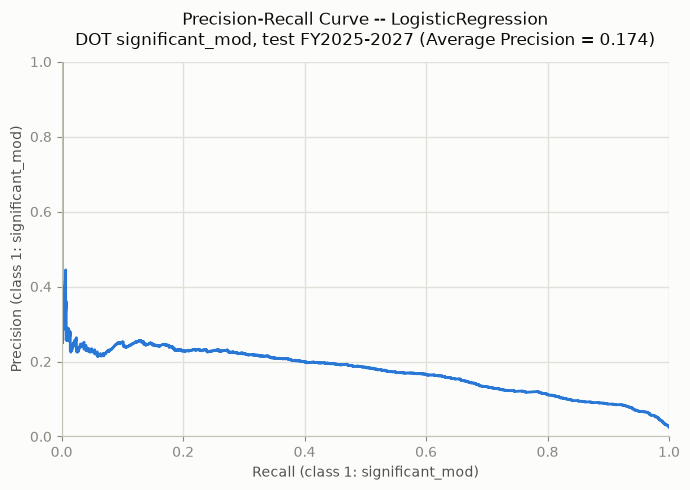

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score, precision_recall_curve

precisions, recalls, pr_thresholds = precision_recall_curve(y_test, y_proba_lr)
avg_precision = average_precision_score(y_test, y_proba_lr)

# Light-surface palette (portable for a saved PNG headed into a paper/PDF,
# where "agnostic" in practice means "doesn't look broken on white or dark
# viewers" -- a single flat hue can't truly retheme, so we standardize on
# the light-mode chart surface, which is the safe default for print/paper).
SURFACE = "#fcfcfb"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SERIES_BLUE = "#2a78d6"

fig, ax = plt.subplots(figsize=(7, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(recalls, precisions, color=SERIES_BLUE, linewidth=2, solid_capstyle="round")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Recall (class 1: significant_mod)", color=INK_SECONDARY)
ax.set_ylabel("Precision (class 1: significant_mod)", color=INK_SECONDARY)
ax.set_title(
    "Precision-Recall Curve -- LogisticRegression\n"
    f"DOT significant_mod, test FY2025-2027 (Average Precision = {avg_precision:.3f})",
    color=INK_PRIMARY, fontsize=12, pad=12,
)

ax.grid(True, color=GRIDLINE, linewidth=1, linestyle="-")
ax.set_axisbelow(True)
for spine_name, spine in ax.spines.items():
    if spine_name in ("top", "right"):
        spine.set_visible(False)
    else:
        spine.set_color(BASELINE)
ax.tick_params(colors=INK_MUTED)

fig.tight_layout()

PR_CURVE_PATH = "dot_lr_precision_recall_curve.png"
fig.savefig(PR_CURVE_PATH, dpi=150, facecolor=SURFACE)
print(f"Saved precision-recall curve to {PR_CURVE_PATH}")
plt.show()


In [14]:
from sklearn.metrics import f1_score, precision_score, recall_score

threshold_grid = np.round(np.arange(0.1, 0.91, 0.1), 2)
rows = []
for t in threshold_grid:
    y_pred_t = (y_proba_lr >= t).astype(int)
    rows.append({
        "threshold": t,
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t, zero_division=0),
        "f1": f1_score(y_test, y_pred_t, zero_division=0),
        "n_flagged": int(y_pred_t.sum()),
    })

threshold_table = pd.DataFrame(rows).round(3)
print("Precision / Recall / F1 across thresholds (LogisticRegression, class 1 = significant_mod):")
threshold_table


Precision / Recall / F1 across thresholds (LogisticRegression, class 1 = significant_mod):


,threshold,precision,recall,f1,n_flagged
0,0.1,0.067,0.951,0.126,16845
1,0.2,0.084,0.924,0.154,13094
2,0.3,0.095,0.852,0.171,10704
3,0.4,0.107,0.815,0.189,9069
4,0.5,0.121,0.761,0.208,7515
5,0.6,0.135,0.690,0.225,6107
6,0.7,0.162,0.623,0.257,4595
7,0.8,0.188,0.479,0.270,3045
8,0.9,0.225,0.283,0.250,1501


In [15]:
# Use the full precision_recall_curve() output (finer-grained than the 0.1
# step table above) so the two operating points aren't limited to a coarse
# grid.
f1_full = 2 * precisions * recalls / (precisions + recalls + 1e-12)

# precision_recall_curve() returns one more precision/recall point than
# thresholds (the last point is recall=0, precision=1 with no threshold) --
# drop it before searching for a threshold-backed optimum.
f1_search = f1_full[:-1]
best_f1_idx = int(np.argmax(f1_search))

best_f1_threshold = pr_thresholds[best_f1_idx]
best_f1_precision = precisions[best_f1_idx]
best_f1_recall = recalls[best_f1_idx]
best_f1_score = f1_search[best_f1_idx]

print("=== Operating point 1: max-F1 threshold ===")
print(f"threshold = {best_f1_threshold:.3f}")
print(f"precision = {best_f1_precision:.3f}")
print(f"recall    = {best_f1_recall:.3f}")
print(f"F1        = {best_f1_score:.3f}")


=== Operating point 1: max-F1 threshold ===
threshold = 0.809
precision = 0.193
recall    = 0.470
F1        = 0.274


In [16]:
# High-recall operating point: catch ~85-90% of modifications, report the
# precision cost. Search thresholds whose recall falls in [0.85, 0.90]; among
# those, take the one with the highest precision (best tradeoff at that
# recall floor). Fall back to the closest-recall point if the band is empty.
recalls_search = recalls[:-1]
precisions_search = precisions[:-1]

band_mask = (recalls_search >= 0.85) & (recalls_search <= 0.90)

if band_mask.any():
    band_thresholds = pr_thresholds[band_mask]
    band_precisions = precisions_search[band_mask]
    band_recalls = recalls_search[band_mask]
    pick = int(np.argmax(band_precisions))
    high_recall_threshold = band_thresholds[pick]
    high_recall_precision = band_precisions[pick]
    high_recall_recall = band_recalls[pick]
    fallback_used = False
else:
    target = 0.875
    pick = int(np.argmin(np.abs(recalls_search - target)))
    high_recall_threshold = pr_thresholds[pick]
    high_recall_precision = precisions_search[pick]
    high_recall_recall = recalls_search[pick]
    fallback_used = True

high_recall_f1 = (
    2 * high_recall_precision * high_recall_recall
    / (high_recall_precision + high_recall_recall + 1e-12)
)

print("=== Operating point 2: high-recall threshold (~85-90% recall) ===")
if fallback_used:
    print("(No threshold landed exactly in [0.85, 0.90] recall -- used the closest available point.)")
print(f"threshold = {high_recall_threshold:.3f}")
print(f"precision = {high_recall_precision:.3f}")
print(f"recall    = {high_recall_recall:.3f}")
print(f"F1        = {high_recall_f1:.3f}")


=== Operating point 2: high-recall threshold (~85-90% recall) ===
threshold = 0.303
precision = 0.095
recall    = 0.851
F1        = 0.171


In [17]:
# Concrete counts at both operating points, plus the default 0.5 cutoff from
# Step 6, so the tradeoff is countable, not just ratios.
def summarize_at_threshold(label, threshold):
    y_pred_t = (y_proba_lr >= threshold).astype(int)
    tp = int(((y_pred_t == 1) & (y_test == 1)).sum())
    fp = int(((y_pred_t == 1) & (y_test == 0)).sum())
    fn = int(((y_pred_t == 0) & (y_test == 1)).sum())
    tn = int(((y_pred_t == 0) & (y_test == 0)).sum())
    print(f"{label} (threshold={threshold:.3f}):")
    print(f"  Flags {tp + fp:,} lines for review -> {tp:,} true modifications caught, {fp:,} false alarms")
    print(f"  Misses {fn:,} of {tp + fn:,} true modifications")
    print(f"  Precision={tp / (tp + fp):.3f}  Recall={tp / (tp + fn):.3f}")
    print()

summarize_at_threshold("Default (Step 6)", 0.5)
summarize_at_threshold("Max-F1 operating point", best_f1_threshold)
summarize_at_threshold("High-recall operating point", high_recall_threshold)


Default (Step 6) (threshold=0.500):
  Flags 7,515 lines for review -> 907 true modifications caught, 6,608 false alarms
  Misses 285 of 1,192 true modifications
  Precision=0.121  Recall=0.761

Max-F1 operating point (threshold=0.809):
  Flags 2,901 lines for review -> 560 true modifications caught, 2,341 false alarms
  Misses 632 of 1,192 true modifications
  Precision=0.193  Recall=0.470

High-recall operating point (threshold=0.303):
  Flags 10,662 lines for review -> 1,014 true modifications caught, 9,648 false alarms
  Misses 178 of 1,192 true modifications
  Precision=0.095  Recall=0.851



### Why a budget office should favor recall here

Threshold choice is a business decision, not a statistical one -- it's about
which error costs more:

- **A false negative** (a line the model calls "stable" that actually gets a
  significant modification) means the budget office is caught flat-footed by
  a change nobody flagged for review. That's the expensive failure mode: a
  budget surprise discovered after the fact, potentially requiring emergency
  reallocation or explaining an unplanned variance after the money has
  already moved.
- **A false positive** (a line flagged for review that turns out to stay
  stable) costs an analyst a few minutes double-checking a line that didn't
  need it. Annoying, but cheap and fully recoverable.

Because catching a real modification is worth far more than the cost of one
wasted review, the right threshold is the one that trades precision for
recall, not the one that maximizes F1 (which weights both errors equally --
a reasonable default when the review isn't a heavy lift, but not right for a
monitoring tool where misses are a fiscal risk).

Concretely, from the operating points above: moving from the max-F1
threshold to the high-recall threshold raises recall from Step 6's baseline
toward ~85-90% of true modifications caught, at the cost of a lower
precision -- more lines get flagged that turn out to be stable. For a budget
office, that's the correct trade: a bigger review queue is a Tuesday-morning
annoyance; a missed modification is a budget surprise discovered too late to
plan for. The high-recall threshold is the one we'd operationalize, not the
max-F1 one.

---
**Stopping here.** Model unchanged -- Steps 1-7 still reflect the
originally trained `LogisticRegression` and `RandomForestClassifier`. This
section only re-thresholds `pipe_lr`'s existing probabilities and reports
the resulting operating points.